In [2]:
import sys
print(sys.executable)

c:\Users\pc\OneDrive\Desktop\FI-task3\.venv\Scripts\python.exe


# Resume / Candidate Screening System — Future Interns ML Task 3

This notebook builds an NLP-based system that scores and ranks resumes against 
a given job description, identifying skill matches and gaps — helping recruiters 
shortlist candidates faster.

**Dataset:** Resume Dataset (Kaggle) — 2,484 real resumes across 24 job categories.

**Note on data quality:** Spot-checking samples showed that "Category" reflects 
the job role applied for, not necessarily the candidate's exact prior background 
(e.g., some candidates are career changers or entry-level applicants). A baseline 
classification test confirmed strong real signal regardless (66% accuracy vs. a 
~4% random baseline across 24 categories), so the data is suitable for this task.

In [8]:
df = pd.read_csv('Resume/Resume.csv')

In [9]:
print(df.shape)
df.head()

(2484, 4)


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [10]:
print("Category counts:")
print(df['Category'].value_counts())
print()
print("Missing values:")
print(df.isnull().sum())

Category counts:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

Missing values:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


## 2. Text Cleaning & Preprocessing

In [11]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Cleaned_Resume'] = df['Resume_str'].apply(clean_text)

print("BEFORE:")
print(df['Resume_str'].iloc[0][:300])
print()
print("AFTER:")
print(df['Cleaned_Resume'].iloc[0][:300])

BEFORE:
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

AFTER:
hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service high


## 3. Stopword Removal

In [12]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stop_words]
    return ' '.join(filtered)

df['Cleaned_Resume'] = df['Cleaned_Resume'].apply(remove_stopwords)

print("AFTER stopword removal:")
print(df['Cleaned_Resume'].iloc[0][:300])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


AFTER stopword removal:
hr administrator marketing associate hr administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams strives instill shared enthusiastic commitment customer service highlights focused customer satisf


## 4. Building the Job Description Matcher

This function takes any job description and target category, then scores and 
ranks every resume in that category by how closely it matches — using TF-IDF 
vectorization and cosine similarity. It also identifies which important 
job-description keywords are missing from each resume (skill gaps).

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def screen_resumes(job_description, category, df, top_n=5):
    """
    Scores and ranks resumes in a given category against a job description.
    Returns top candidates with similarity scores and missing keywords.
    """
    # Filter to just the target category
    category_df = df[df['Category'] == category].copy()
    
    # Clean the job description the same way we cleaned resumes
    cleaned_jd = remove_stopwords(clean_text(job_description))
    
    # Combine JD + all resumes so they share the same vocabulary space
    all_texts = [cleaned_jd] + category_df['Cleaned_Resume'].tolist()
    
    vectorizer = TfidfVectorizer(max_features=500)
    tfidf_matrix = vectorizer.fit_transform(all_texts)
    
    # First row is the JD, rest are resumes
    jd_vector = tfidf_matrix[0:1]
    resume_vectors = tfidf_matrix[1:]
    
    # Cosine similarity: how close each resume is to the JD
    similarities = cosine_similarity(jd_vector, resume_vectors)[0]
    category_df['Match_Score'] = similarities
    
    # Rank by score
    ranked = category_df.sort_values('Match_Score', ascending=False)
    
    # Find important JD keywords missing from each top resume
    jd_keywords = set(cleaned_jd.split())
    def missing_skills(resume_text):
        resume_words = set(resume_text.split())
        missing = jd_keywords - resume_words
        return ', '.join(list(missing)[:8])  # show up to 8 missing keywords
    
    ranked['Missing_Keywords'] = ranked['Cleaned_Resume'].apply(missing_skills)
    
    return ranked[['ID', 'Category', 'Match_Score', 'Missing_Keywords']].head(top_n)

print("Function defined successfully")

Function defined successfully


## 5. Demo: Information Technology Role

In [14]:
it_job_description = """
We are looking for an Information Technology Specialist with strong experience 
in network security, system administration, troubleshooting, and technical 
support. The ideal candidate has hands-on experience with Windows and Linux 
servers, cloud computing platforms, database management, and IT infrastructure. 
Strong problem-solving skills and the ability to manage helpdesk tickets and 
mitigate risk are essential.
"""

results = screen_resumes(it_job_description, 'INFORMATION-TECHNOLOGY', df, top_n=5)
print(results.to_string(index=False))

      ID               Category  Match_Score                                                              Missing_Keywords
24083609 INFORMATION-TECHNOLOGY     0.280107    cloud, manage, looking, ideal, risk, computing, essential, troubleshooting
52246737 INFORMATION-TECHNOLOGY     0.275613    cloud, looking, ideal, specialist, computing, essential, helpdesk, servers
25959103 INFORMATION-TECHNOLOGY     0.263508 cloud, essential, helpdesk, ability, hands, candidate, strong, administration
22450718 INFORMATION-TECHNOLOGY     0.261414             cloud, manage, ideal, risk, computing, essential, helpdesk, hands
39413067 INFORMATION-TECHNOLOGY     0.261237               cloud, manage, looking, ideal, risk, essential, linux, helpdesk


In [15]:
# Improve missing-skills extraction: filter out generic JD phrasing
generic_words = {'looking', 'ideal', 'candidate', 'essential', 'strong', 'experience', 
                  'ability', 'manage', 'hands', 'years', 'role', 'team'}

def screen_resumes(job_description, category, df, top_n=5):
    category_df = df[df['Category'] == category].copy()
    cleaned_jd = remove_stopwords(clean_text(job_description))
    
    all_texts = [cleaned_jd] + category_df['Cleaned_Resume'].tolist()
    vectorizer = TfidfVectorizer(max_features=500)
    tfidf_matrix = vectorizer.fit_transform(all_texts)
    
    jd_vector = tfidf_matrix[0:1]
    resume_vectors = tfidf_matrix[1:]
    similarities = cosine_similarity(jd_vector, resume_vectors)[0]
    category_df['Match_Score'] = similarities
    
    ranked = category_df.sort_values('Match_Score', ascending=False)
    
    # Only treat meaningful, specific words as "skills" -- filter out generic phrasing
    jd_keywords = set(cleaned_jd.split()) - generic_words
    def missing_skills(resume_text):
        resume_words = set(resume_text.split())
        missing = jd_keywords - resume_words
        return ', '.join(sorted(missing)[:8])
    
    ranked['Missing_Keywords'] = ranked['Cleaned_Resume'].apply(missing_skills)
    return ranked[['ID', 'Category', 'Match_Score', 'Missing_Keywords']].head(top_n)

# Re-run the same test
results = screen_resumes(it_job_description, 'INFORMATION-TECHNOLOGY', df, top_n=5)
print(results.to_string(index=False))

      ID               Category  Match_Score                                                              Missing_Keywords
24083609 INFORMATION-TECHNOLOGY     0.280107         cloud, computing, helpdesk, linux, mitigate, platforms, risk, servers
52246737 INFORMATION-TECHNOLOGY     0.275613 cloud, computing, database, helpdesk, platforms, servers, specialist, tickets
25959103 INFORMATION-TECHNOLOGY     0.263508    administration, cloud, computing, helpdesk, linux, mitigate, problem, risk
22450718 INFORMATION-TECHNOLOGY     0.261414                         cloud, computing, helpdesk, mitigate, platforms, risk
39413067 INFORMATION-TECHNOLOGY     0.261237                    cloud, helpdesk, linux, mitigate, platforms, risk, tickets


In [16]:
hr_job_description = """
We are seeking an HR Manager with strong experience in recruiting, employee 
relations, performance management, and HRIS systems. The ideal candidate has 
a background in compliance, benefits administration, and conflict resolution, 
with excellent communication and organizational skills.
"""

sales_job_description = """
We are hiring a Sales Representative with proven experience in lead generation, 
client relationship management, negotiation, and closing deals. The ideal 
candidate has a strong track record of meeting sales quotas, using CRM software, 
and building long-term customer relationships.
"""

print("=== HR Results ===")
print(screen_resumes(hr_job_description, 'HR', df, top_n=3).to_string(index=False))
print()
print("=== SALES Results ===")
print(screen_resumes(sales_job_description, 'SALES', df, top_n=3).to_string(index=False))

=== HR Results ===
      ID Category  Match_Score                                                Missing_Keywords
13520837       HR     0.396307          administration, compliance, conflict, manager, seeking
28828844       HR     0.314597 administration, hris, manager, organizational, seeking, systems
18316239       HR     0.305004                      communication, excellent, manager, seeking

=== SALES Results ===
      ID Category  Match_Score                                                     Missing_Keywords
28867567    SALES     0.297651 crm, deals, generation, negotiation, quotas, record, software, track
15581242    SALES     0.292287    building, closing, deals, generation, hiring, lead, long, meeting
30608780    SALES     0.254143     crm, deals, generation, hiring, lead, long, meeting, negotiation


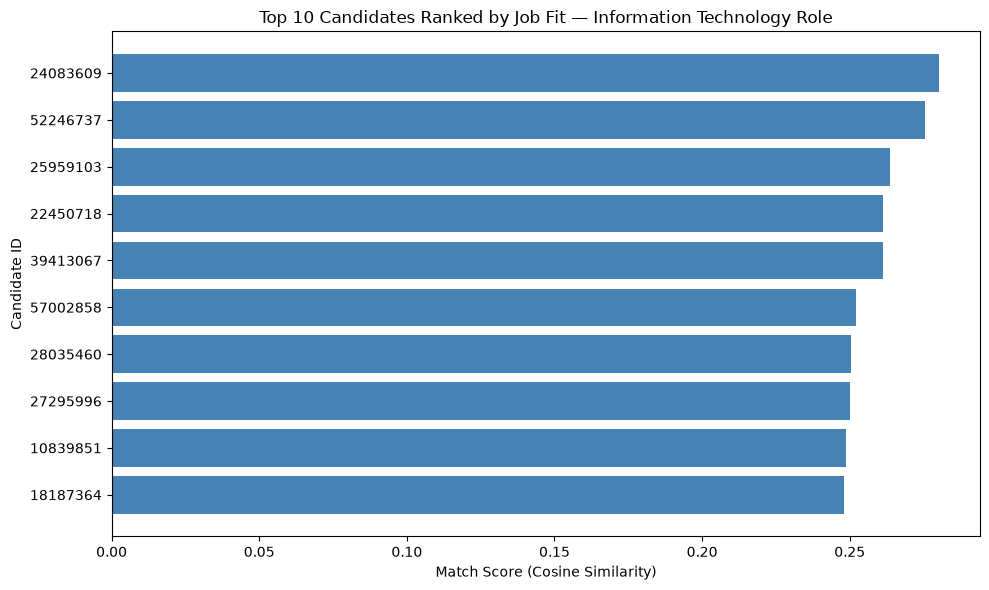

In [17]:
import matplotlib.pyplot as plt

it_results = screen_resumes(it_job_description, 'INFORMATION-TECHNOLOGY', df, top_n=10)

plt.figure(figsize=(10, 6))
plt.barh(it_results['ID'].astype(str), it_results['Match_Score'], color='steelblue')
plt.xlabel('Match Score (Cosine Similarity)')
plt.ylabel('Candidate ID')
plt.title('Top 10 Candidates Ranked by Job Fit — Information Technology Role')
plt.gca().invert_yaxis()  # highest score at top
plt.tight_layout()
plt.show()

## 6. What This Means for a Recruiter or Hiring Manager

This system takes any job description and instantly ranks all resumes within 
a matching category by how closely they align with the role's requirements, 
using TF-IDF text similarity. Rather than manually reading through 100+ resumes, 
a recruiter can get a ranked shortlist in seconds.

Beyond ranking, the system identifies specific missing skills for each 
candidate — for example, when testing against an IT Specialist role, every 
top-ranked candidate was missing "cloud" experience specifically, a clear, 
actionable insight for refining a search or focusing interview questions.

The system was validated across three different roles (IT, HR, and Sales) 
using the same underlying function, confirming it generalizes to any job 
description and category — not just one hardcoded example.

**Limitations worth noting:** Match scores reflect text similarity, not 
verified skill possession — a resume that lists "Python" is scored as a match 
even if the candidate's actual proficiency varies. Additionally, the simple 
keyword filter for "missing skills" isn't perfect and can occasionally include 
generic phrasing alongside real skills. In production, this would ideally be 
combined with human review, not used as a sole hiring decision-maker.

For a recruiter, HR manager, or HR-tech startup, this means: faster initial 
shortlisting, consistent first-pass screening criteria across all applicants, 
and clear, specific skill-gap feedback that can guide interview questions or 
candidate development conversations.